In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

In [ ]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("File loaded ✅")
df.head()

Saving noida_aqi_3years.csv to noida_aqi_3years (1).csv
File loaded ✅


,Date,AQI
0,21-03-2023,240
1,22-03-2023,225
2,23-03-2023,245
3,24-03-2023,267
4,25-03-2023,223


In [ ]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()

df = df.dropna()

df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df = df.sort_values('date')

In [ ]:
# Lag features
df['lag1'] = df['aqi'].shift(1)
df['lag2'] = df['aqi'].shift(2)
df['lag3'] = df['aqi'].shift(3)

# Moving averages
df['ma2'] = df['aqi'].rolling(2).mean()
df['ma5'] = df['aqi'].rolling(5).mean()
df['ma10'] = df['aqi'].rolling(10).mean()

# Volatility
df['std5'] = df['aqi'].rolling(5).std()


df['lag_diff'] = df['aqi'] - df['lag1']

# Target = next day AQI
df['target'] = df['aqi'].shift(-1)

df = df.dropna()

In [ ]:
features = [
    'lag1','lag2','lag3',
    'ma2','ma5','ma10',
    'std5',

    'lag_diff'
]

X = df[features]
y = df['target']

split = int(len(df)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=1000,
    max_depth=20,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, n_estimators=1000, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
last_known = df.copy()

predictions = []

for i in range(5):
    last_row = last_known.iloc[-1]


    input_data = [[
        last_row['lag1'],
        last_row['lag2'],
        last_row['lag3'],
        last_known['aqi'].tail(2).mean(),
        last_known['aqi'].tail(5).mean(),
        last_known['aqi'].tail(10).mean(),
        last_known['aqi'].tail(5).std(),

        last_row['lag_diff']
    ]]


    next_aqi = model.predict(input_data)[0]
    predictions.append(next_aqi)


    new_row = last_row.copy()
    new_row['aqi'] = next_aqi


    new_row['lag1'] = next_aqi
    new_row['lag2'] = last_row['lag1']
    new_row['lag3'] = last_row['lag2']

    new_row['change'] = next_aqi - last_row['aqi']
    new_row['lag_diff'] = new_row['change']
    new_row['spike_flag'] = int(next_aqi > 250)


    last_known = pd.concat([last_known, new_row.to_frame().T], ignore_index=True)

# Output
for i, val in enumerate(predictions, 1):
    print(f"Day {i} Prediction:", val)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Day 1 Prediction: 224.97199944090997
Day 2 Prediction: 223.734511528822
Day 3 Prediction: 217.463818488529
Day 4 Prediction: 220.9240307928913
Day 5 Prediction: 211.558


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


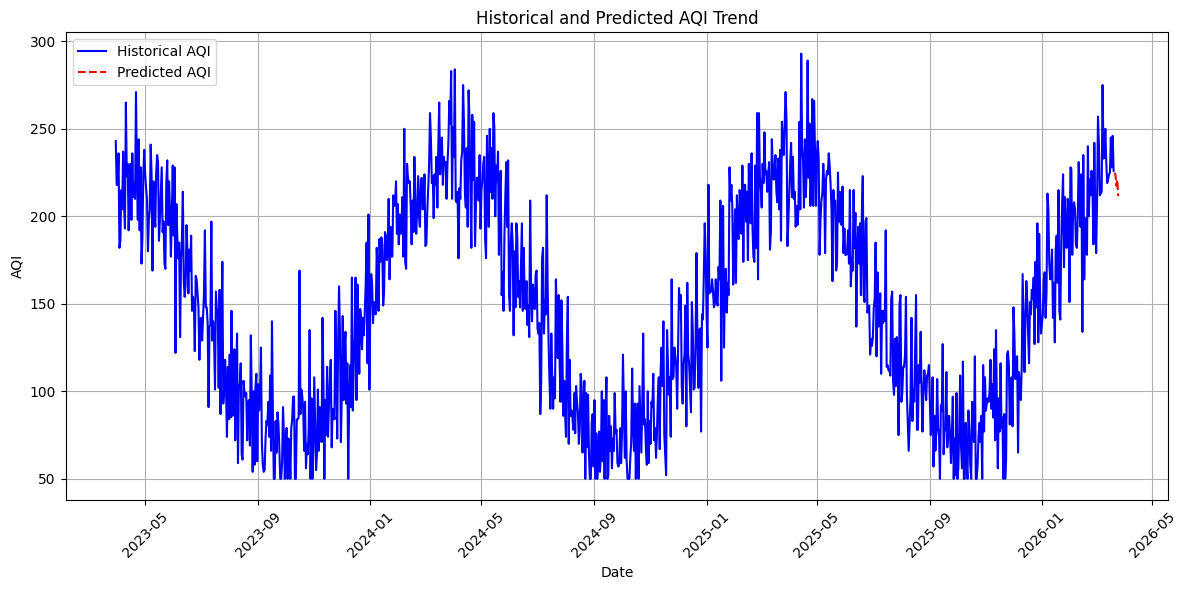

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Get the last date from the historical DataFrame
last_historical_date = df['date'].max()

# Generate future dates for predictions
future_dates = pd.date_range(start=last_historical_date + pd.Timedelta(days=1), periods=len(predictions))

# Create a DataFrame for predictions
predictions_df = pd.DataFrame({'date': future_dates, 'aqi': predictions})

# Combine historical and predicted data for plotting
combined_df = pd.concat([df[['date', 'aqi']], predictions_df])

plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['aqi'], label='Historical AQI', color='blue')
plt.plot(predictions_df['date'], predictions_df['aqi'], label='Predicted AQI', color='red', linestyle='--')

plt.title('Historical and Predicted AQI Trend')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()